 Introduction to Machine Learning

## Practice class 02 - Decision Trees

**Introduction**

Decision tree is a fundamental machine learning algorithm used for both classification and regression tasks. They model decisions and their possible consequences as a tree-like structure, making them intuitive and easy to interpret.

**Key Concepts**
 * **Root Node:** The starting point of the tree representing the entire dataset.
 * **Internal Nodes:** Decision points based on feature conditions.
 * **Leaf Nodes (Terminal Nodes):** Final output labels or values.
 * **Branches:** Represent the outcome of a decision rule leading to the next node.

 ![dectree](https://k21academy.com/wp-content/uploads/2020/12/decision.png)

### Demo with random points
Recall our fist example from the kNN class:

Consider 3 points in a two dimensional space $(0,0)$, $(1,0)$, $(0,1)$. Around each point generate a cloud of 30 random points with normal distribution and $\sigma=0.25$. Use 42 for the random seed. This way we have a 2 dimensional feature space with 3 species. This is going to be your train dataset.

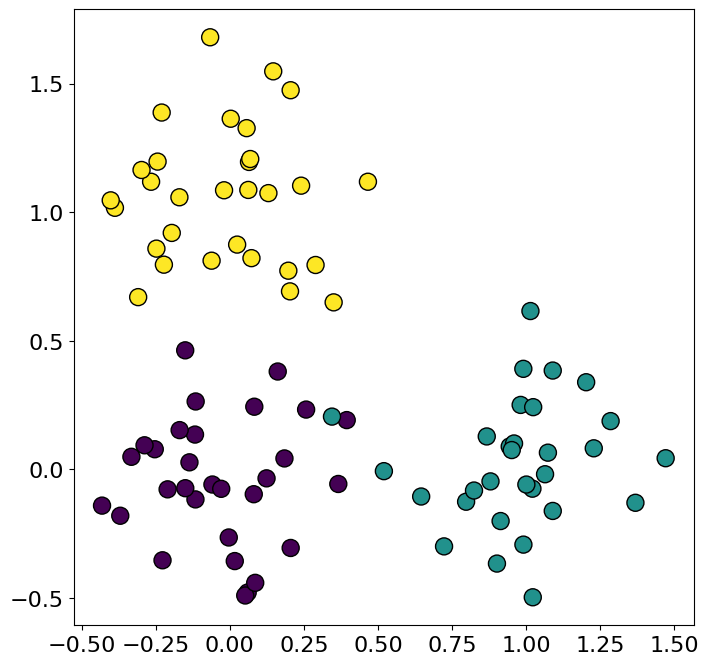

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

rcParams['font.size']=16

a=np.array([0,0])
b=np.array([1,0])
c=np.array([0,1])
triangle=np.array([a,b,c])
n=30

np.random.seed(42)
x_train=np.random.normal(loc=0.0,scale=0.25,size=(3*n,2))
x_train[:n,:] += a
x_train[n:2*n,:] += b
x_train[2*n:3*n,:] += c
y_train = np.array(n*[0]+n*[1]+n*[2])

fig,ax = plt.subplots(1,1,figsize=(8,8))
im=ax.scatter(x_train[:,0],x_train[:,1],c=y_train,cmap='viridis',ec='k',s=150)


Now lets chech how a decision tree deals with this taks.

In [2]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.inspection import DecisionBoundaryDisplay

In [3]:
clf = DecisionTreeClassifier(max_depth=4,criterion='gini')
clf.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.6666666666666666, 0.9, 'x[1] <= 0.633\ngini = 0.667\nsamples = 90\nvalue = [30, 30, 30]'),
 Text(0.5, 0.7, 'x[0] <= 0.458\ngini = 0.5\nsamples = 60\nvalue = [30, 30, 0]'),
 Text(0.5833333333333333, 0.8, 'True  '),
 Text(0.3333333333333333, 0.5, 'x[0] <= 0.301\ngini = 0.062\nsamples = 31\nvalue = [30, 1, 0]'),
 Text(0.16666666666666666, 0.3, 'gini = 0.0\nsamples = 28\nvalue = [28, 0, 0]'),
 Text(0.5, 0.3, 'x[0] <= 0.356\ngini = 0.444\nsamples = 3\nvalue = [2, 1, 0]'),
 Text(0.3333333333333333, 0.1, 'gini = 0.0\nsamples = 1\nvalue = [0, 1, 0]'),
 Text(0.6666666666666666, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [2, 0, 0]'),
 Text(0.6666666666666666, 0.5, 'gini = 0.0\nsamples = 29\nvalue = [0, 29, 0]'),
 Text(0.8333333333333334, 0.7, 'gini = 0.0\nsamples = 30\nvalue = [0, 0, 30]'),
 Text(0.75, 0.8, '  False')]

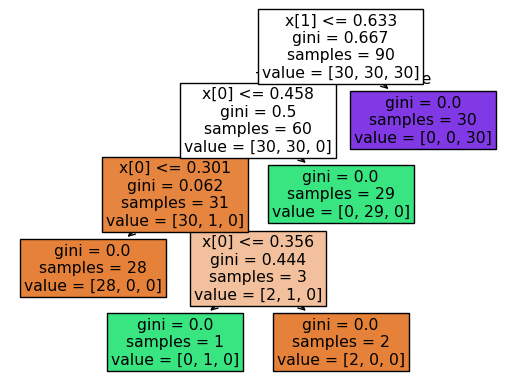

In [4]:
plot_tree(clf,filled=True)

<Figure size 640x480 with 0 Axes>

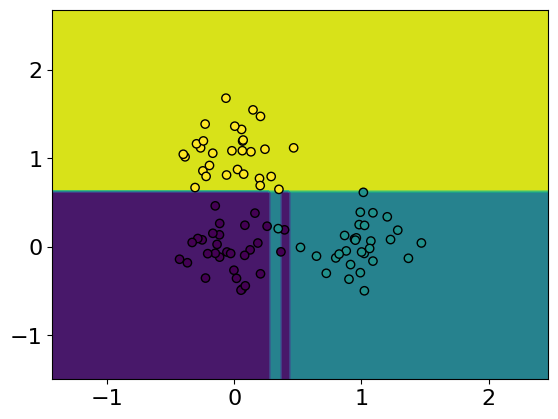

In [5]:
plt.figure()
DecisionBoundaryDisplay.from_estimator(
        clf,
        x_train,
        cmap=plt.cm.viridis,
        response_method="predict",
    )
plt.scatter(x_train[:,0],x_train[:,1],c=y_train,edgecolor="black")

**Note that the boundaries are parallel to the coordinate axes!**

### Demo - Lets play tennis, or not?
This is a short intro how to apply decision trees for datasets with categorical data. We use a short dataset, containing 14 days of weather data, with a target coloumn of play tennis or not.

In [7]:
tennis = np.genfromtxt("tennis.txt",dtype='S10')

In [8]:
f = open("tennis.txt","r")
lines = list(f.readlines())
f.close()
names = lines[0].split()
print(names)

['#Day', 'Outlook', 'Temperature', 'Humidity', 'Wind', 'PlayTennis']


In [9]:
tennis

array([[b'D1', b'Sunny', b'Hot', b'High', b'Weak', b'No'],
       [b'D2', b'Sunny', b'Hot', b'High', b'Strong', b'No'],
       [b'D3', b'Overcast', b'Hot', b'High', b'Weak', b'Yes'],
       [b'D4', b'Rain', b'Mild', b'High', b'Weak', b'Yes'],
       [b'D5', b'Rain', b'Cool', b'Normal', b'Weak', b'Yes'],
       [b'D6', b'Rain', b'Cool', b'Normal', b'Strong', b'No'],
       [b'D7', b'Overcast', b'Cool', b'Normal', b'Strong', b'Yes'],
       [b'D8', b'Sunny', b'Mild', b'High', b'Weak', b'No'],
       [b'D9', b'Sunny', b'Cool', b'Normal', b'Weak', b'Yes'],
       [b'D10', b'Rain', b'Mild', b'Normal', b'Weak', b'Yes'],
       [b'D11', b'Sunny', b'Mild', b'Normal', b'Strong', b'Yes'],
       [b'D12', b'Overcast', b'Mild', b'High', b'Strong', b'Yes'],
       [b'D13', b'Overcast', b'Hot', b'Normal', b'Weak', b'Yes'],
       [b'D14', b'Rain', b'Mild', b'High', b'Strong', b'No']],
      dtype='|S10')

In [10]:
from sklearn.preprocessing import LabelEncoder # to process categorical data

xtrans = LabelEncoder()
ytrans = LabelEncoder()
X = xtrans.fit_transform(tennis[:,:-1].flatten()).reshape(tennis[:,:-1].shape)
y = ytrans.fit_transform(tennis[:,-1])

In [11]:
X,y

(array([[ 1, 22, 16, 15, 23],
        [ 7, 22, 16, 15, 21],
        [ 8, 19, 16, 15, 23],
        [ 9, 20, 17, 15, 23],
        [10, 20,  0, 18, 23],
        [11, 20,  0, 18, 21],
        [12, 19,  0, 18, 21],
        [13, 22, 17, 15, 23],
        [14, 22,  0, 18, 23],
        [ 2, 20, 17, 18, 23],
        [ 3, 22, 17, 18, 21],
        [ 4, 19, 17, 15, 21],
        [ 5, 19, 16, 18, 23],
        [ 6, 20, 17, 15, 21]]),
 array([0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0]))

In [12]:
clf = DecisionTreeClassifier(criterion="entropy")

In [13]:
clf.fit(X,y)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.4444444444444444, 0.9, 'Outlook <= 19.5\nentropy = 0.94\nsamples = 14\nvalue = [5, 9]\nclass = yes'),
 Text(0.3333333333333333, 0.7, 'entropy = 0.0\nsamples = 4\nvalue = [0, 4]\nclass = yes'),
 Text(0.38888888888888884, 0.8, 'True  '),
 Text(0.5555555555555556, 0.7, 'Humidity <= 16.5\nentropy = 1.0\nsamples = 10\nvalue = [5, 5]\nclass = no'),
 Text(0.5, 0.8, '  False'),
 Text(0.3333333333333333, 0.5, 'Outlook <= 21.0\nentropy = 0.722\nsamples = 5\nvalue = [4, 1]\nclass = no'),
 Text(0.2222222222222222, 0.3, 'Wind <= 22.0\nentropy = 1.0\nsamples = 2\nvalue = [1, 1]\nclass = no'),
 Text(0.1111111111111111, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [1, 0]\nclass = no'),
 Text(0.3333333333333333, 0.1, 'entropy = 0.0\nsamples = 1\nvalue = [0, 1]\nclass = yes'),
 Text(0.4444444444444444, 0.3, 'entropy = 0.0\nsamples = 3\nvalue = [3, 0]\nclass = no'),
 Text(0.7777777777777778, 0.5, 'Wind <= 22.0\nentropy = 0.722\nsamples = 5\nvalue = [1, 4]\nclass = yes'),
 Text(0.6666666666666666, 0.

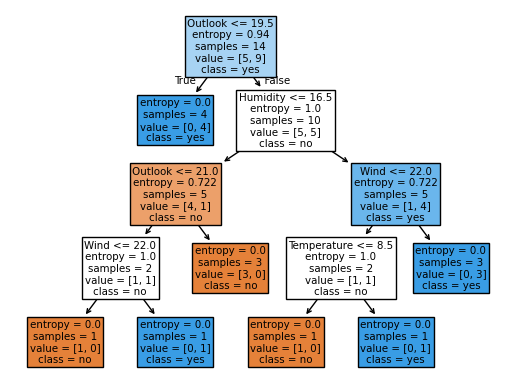

In [14]:
plot_tree(clf,feature_names=names,class_names=['no','yes'],filled=True)

### Task 1 - Gini impurity and entropy
In this task you will learn about the splitting criteria for decisions trees. There are two type of metrics applied for splitting:
* **Gini impurity:**  measures how impure or mixed a dataset is in terms of classification labels. It quantifies how often a randomly chosen element from the dataset would be incorrectly classified if randomly labeled according to the class distribution.
    $$
    I_G=1-\sum_i p_i^2
    $$

* **von Neumann entropy:** measures the uncertainty or disorder in a dataset. The goal of a decision tree is to reduce entropy by making splits that create purer subsets of data.
    $$
    H=-\sum_i p_i \text{log}_2(p_i)
    $$

1. In order to understand these quantites consider two classes and plot the Gini impurity and the von Neumann entory for $p_1\in[0,1]$. What is the value of the metrics for the pure and the most disordered cases? Note that $p_2=1-p_1$.
2. Now we have three classes. Calculate and plot the metrics for $p_1\in[0,1]$ and $p_2\in[0,1]$. Note that $p_3=1-p_1-p_2$, but with the constraint $p_1+p_2<1$. Use a heatmap plot.

In [15]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

rcParams['font.size']=16

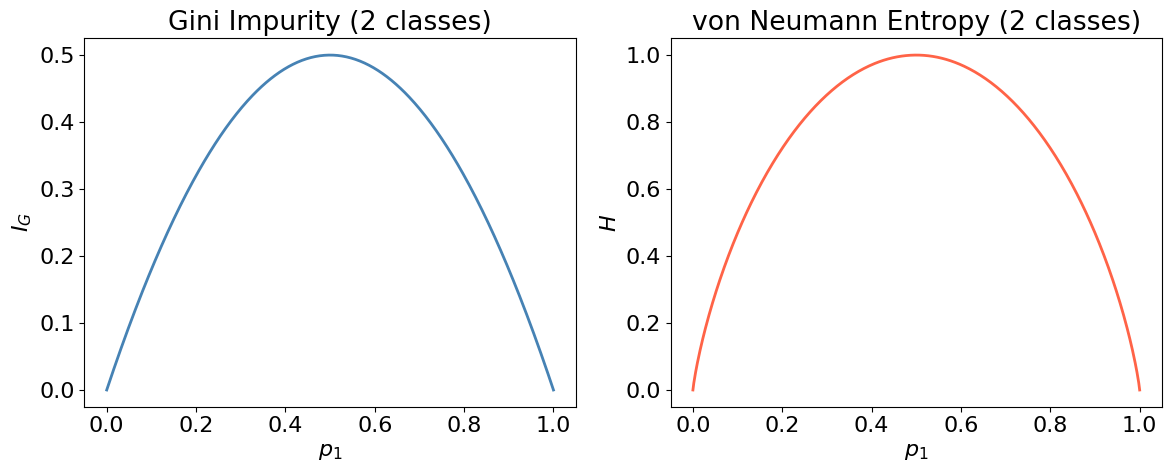

In [ ]:
# ── Part 1: Two classes ───
p1 = np.linspace(0, 1, 500)
p2 = 1 - p1

# Gini impurity
gini2 = 1 - (p1**2 + p2**2)

# von Neumann entropy  (handle p=0 via masking to avoid log(0))
with np.errstate(divide='ignore', invalid='ignore'):
    H2 = -np.where(p1 > 0, p1 * np.log2(p1), 0) \
         -np.where(p2 > 0, p2 * np.log2(p2), 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(p1, gini2, color='steelblue', lw=2)
axes[0].set_xlabel(r'$p_1$')
axes[0].set_ylabel(r'$I_G$')
axes[0].set_title('Gini Impurity (2 classes)')

axes[1].plot(p1, H2, color='tomato', lw=2)
axes[1].set_xlabel(r'$p_1$')
axes[1].set_ylabel(r'$H$')
axes[1].set_title('von Neumann Entropy (2 classes)')

plt.tight_layout()
plt.show()

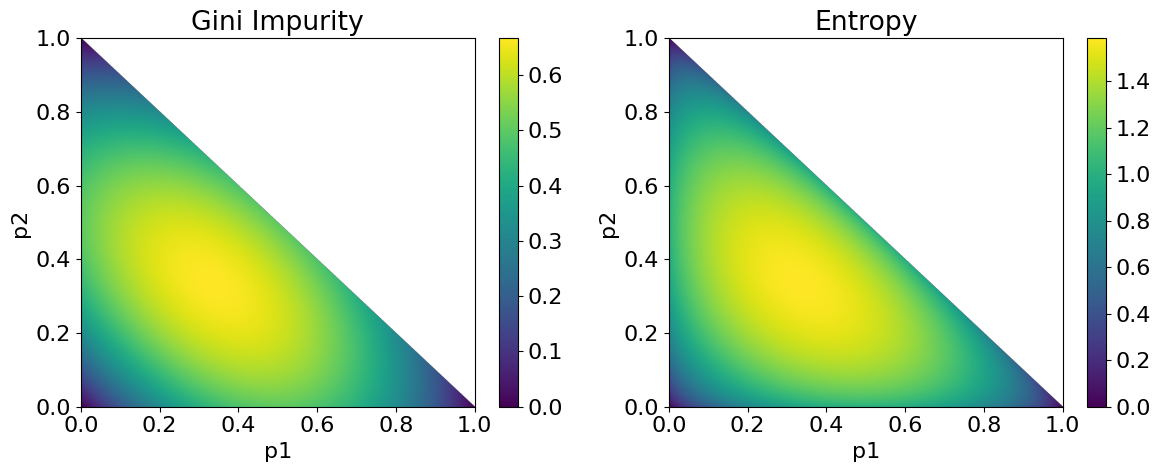

In [ ]:
# ── Part 2: Three classes ───
# Create grid once
P1, P2 = np.meshgrid(np.linspace(0, 1, 500), np.linspace(0, 1, 500))

# Compute P3
P3 = 1 - P1 - P2

# Mask invalid region (where p1 + p2 > 1)
mask = (P1 + P2) > 1

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gini impurity
gini_grid = 1 - (P1**2 + P2**2 + P3**2)
gini_grid[mask.T] = np.nan

# von Neumann entropy  (handle p=0 via masking to avoid log(0))
with np.errstate(divide='ignore', invalid='ignore'):
    H_grid = -np.where(P1 > 0, P1 * np.log2(P1), 0) \
             -np.where(P2 > 0, P2 * np.log2(P2), 0) \
             -np.where(P3 > 0, P3 * np.log2(P3), 0)
H_grid[mask.T] = np.nan

for ax, data, title in zip(axes, [gini_grid, H_grid], ['Gini Impurity', 'Entropy']):
    im = ax.imshow(data, origin='lower', extent=[0,1,0,1], aspect='auto', cmap='viridis')
    plt.colorbar(im, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('p1')
    ax.set_ylabel('p2')

plt.tight_layout()
plt.show()

### Task 2 - Make a decision by hand 
Use the iris dataset and determine the **Root node** of the decision tree both for the Gini impurity and the von Neumann entropy. For that look for the split which minimize the total Gini impurity or the total entropy. 

1. What is the Gini impurity and the entripy of the dataset?
2. Write a helper function, going to be useful in this exercise. The function, `purity(X,y,metric)`, takes a dataset and a metric as a string and calculates the Gini impurity or the entropy of the dataset based on the `metric` arguments.
3. Select one feature, and split the data based on a threshold value of this feature. Calculate the gini/entropy of the two subsets and the total gini/entropy defined as the average of the subset values weighted by the element numbers of the subsets.
4. Split the dataset between all possible values of the given feature and plot the total gini/entropy as a function of the threshold value.
5. Repeat the previous step for all the other features, what do we have to split the data in the root node?

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

In [30]:
# ── 1. Gini impurity and entropy of the full dataset ───

def gini(probs):
    return 1 - np.sum(probs**2)

def entropy(probs):
    # von Neumann / Shannon entropy (base 2)
    probs = probs[probs > 0]          # avoid log(0)
    return -np.sum(probs * np.log2(probs))

def class_probs(y_subset):
    counts = np.bincount(y_subset, minlength=3)
    return counts / len(y_subset)

p = class_probs(y)
print("=== Full dataset ===")
print(f"  Class probabilities : {p}")
print(f"  Gini impurity       : {gini(p):.4f}")
print(f"  Entropy             : {entropy(p):.4f}")


=== Full dataset ===
  Class probabilities : [0.33333333 0.33333333 0.33333333]
  Gini impurity       : 0.6667
  Entropy             : 1.5850


In [ ]:
# ── 2. Helper function purity(X, y, metric) ───

def purity(X, y, metric):
    """
    Compute the Gini impurity or entropy of dataset (X, y).

    Parameters
    ----------
    X      : array-like, shape (n_samples, n_features)  – feature matrix
    y      : array-like, shape (n_samples,)              – class labels
    metric : str, 'gini' or 'entropy'

    Returns
    -------
    float : impurity / entropy value
    """
    probs = class_probs(np.asarray(y))
    if metric == 'gini':
        return gini(probs)
    elif metric == 'entropy':
        return entropy(probs)
    else:
        raise ValueError(f"Unknown metric '{metric}'. Use 'gini' or 'entropy'.")

print("\n=== purity() on full dataset ===")
print(f"  Gini    : {purity(X, y, 'gini'):.4f}")
print(f"  Entropy : {purity(X, y, 'entropy'):.4f}")



=== purity() on full dataset ===
  Gini    : 0.6667
  Entropy : 1.5850


In [32]:
# ── 3. Single feature / single threshold example ───
def total_purity_after_split(X, y, feature_idx, threshold, metric):
    """Weighted average purity of left and right child nodes."""
    mask = X[:, feature_idx] <= threshold
    y_left, y_right = y[mask], y[~mask]
    n = len(y)
    if len(y_left) == 0 or len(y_right) == 0:
        return purity(X, y, metric)          # degenerate split

    weighted = (len(y_left)  / n) * purity(X[mask],  y_left,  metric) + \
               (len(y_right) / n) * purity(X[~mask], y_right, metric)
    return weighted

# Example: feature 2 (petal length), threshold = 2.45
feat_idx   = 2
threshold  = 2.45

for metric in ('gini', 'entropy'):
    mask = X[:, feat_idx] <= threshold
    p_left  = purity(X[mask],  y[mask],  metric)
    p_right = purity(X[~mask], y[~mask], metric)
    total   = total_purity_after_split(X, y, feat_idx, threshold, metric)
    print(f"\n=== Example split: '{feature_names[feat_idx]}' ≤ {threshold} | metric={metric} ===")
    print(f"  Left  subset (n={mask.sum():3d}) purity : {p_left:.4f}")
    print(f"  Right subset (n={(~mask).sum():3d}) purity : {p_right:.4f}")
    print(f"  Total weighted purity             : {total:.4f}")



=== Example split: 'petal length (cm)' ≤ 2.45 | metric=gini ===
  Left  subset (n= 50) purity : 0.0000
  Right subset (n=100) purity : 0.5000
  Total weighted purity             : 0.3333

=== Example split: 'petal length (cm)' ≤ 2.45 | metric=entropy ===
  Left  subset (n= 50) purity : -0.0000
  Right subset (n=100) purity : 1.0000
  Total weighted purity             : 0.6667


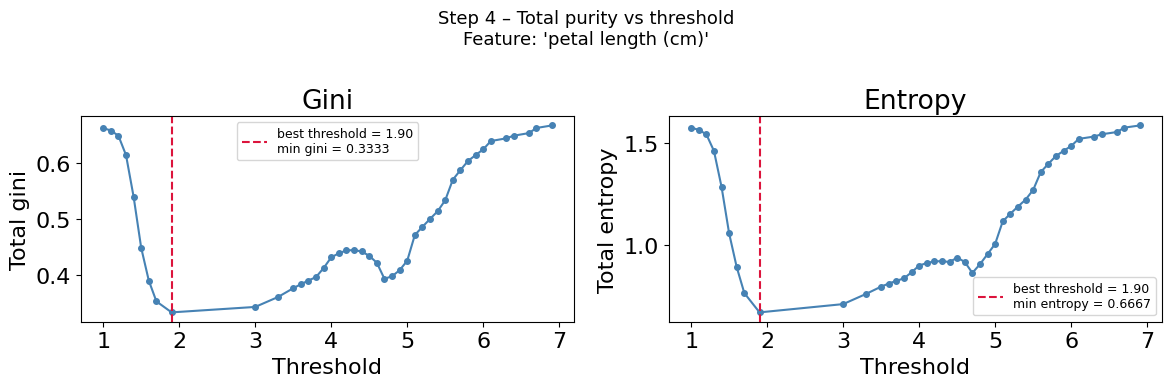

In [35]:
# ── 4. Plot total purity vs threshold for one feature ──
feat_idx = 2  # petal length (index 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle(f"Step 4 – Total purity vs threshold\nFeature: '{feature_names[feat_idx]}'", fontsize=13)

for ax, metric in zip(axes, ('gini', 'entropy')):
    thresholds = np.unique(X[:, feat_idx])          # one candidate per unique value
    totals = [total_purity_after_split(X, y, feat_idx, t, metric) for t in thresholds]

    best_idx = np.argmin(totals)
    ax.plot(thresholds, totals, marker='o', markersize=4, color='steelblue')
    ax.axvline(thresholds[best_idx], color='crimson', linestyle='--',
               label=f"best threshold = {thresholds[best_idx]:.2f}\nmin {metric} = {totals[best_idx]:.4f}")
    ax.set_xlabel("Threshold")
    ax.set_ylabel(f"Total {metric}")
    ax.set_title(metric.capitalize())
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

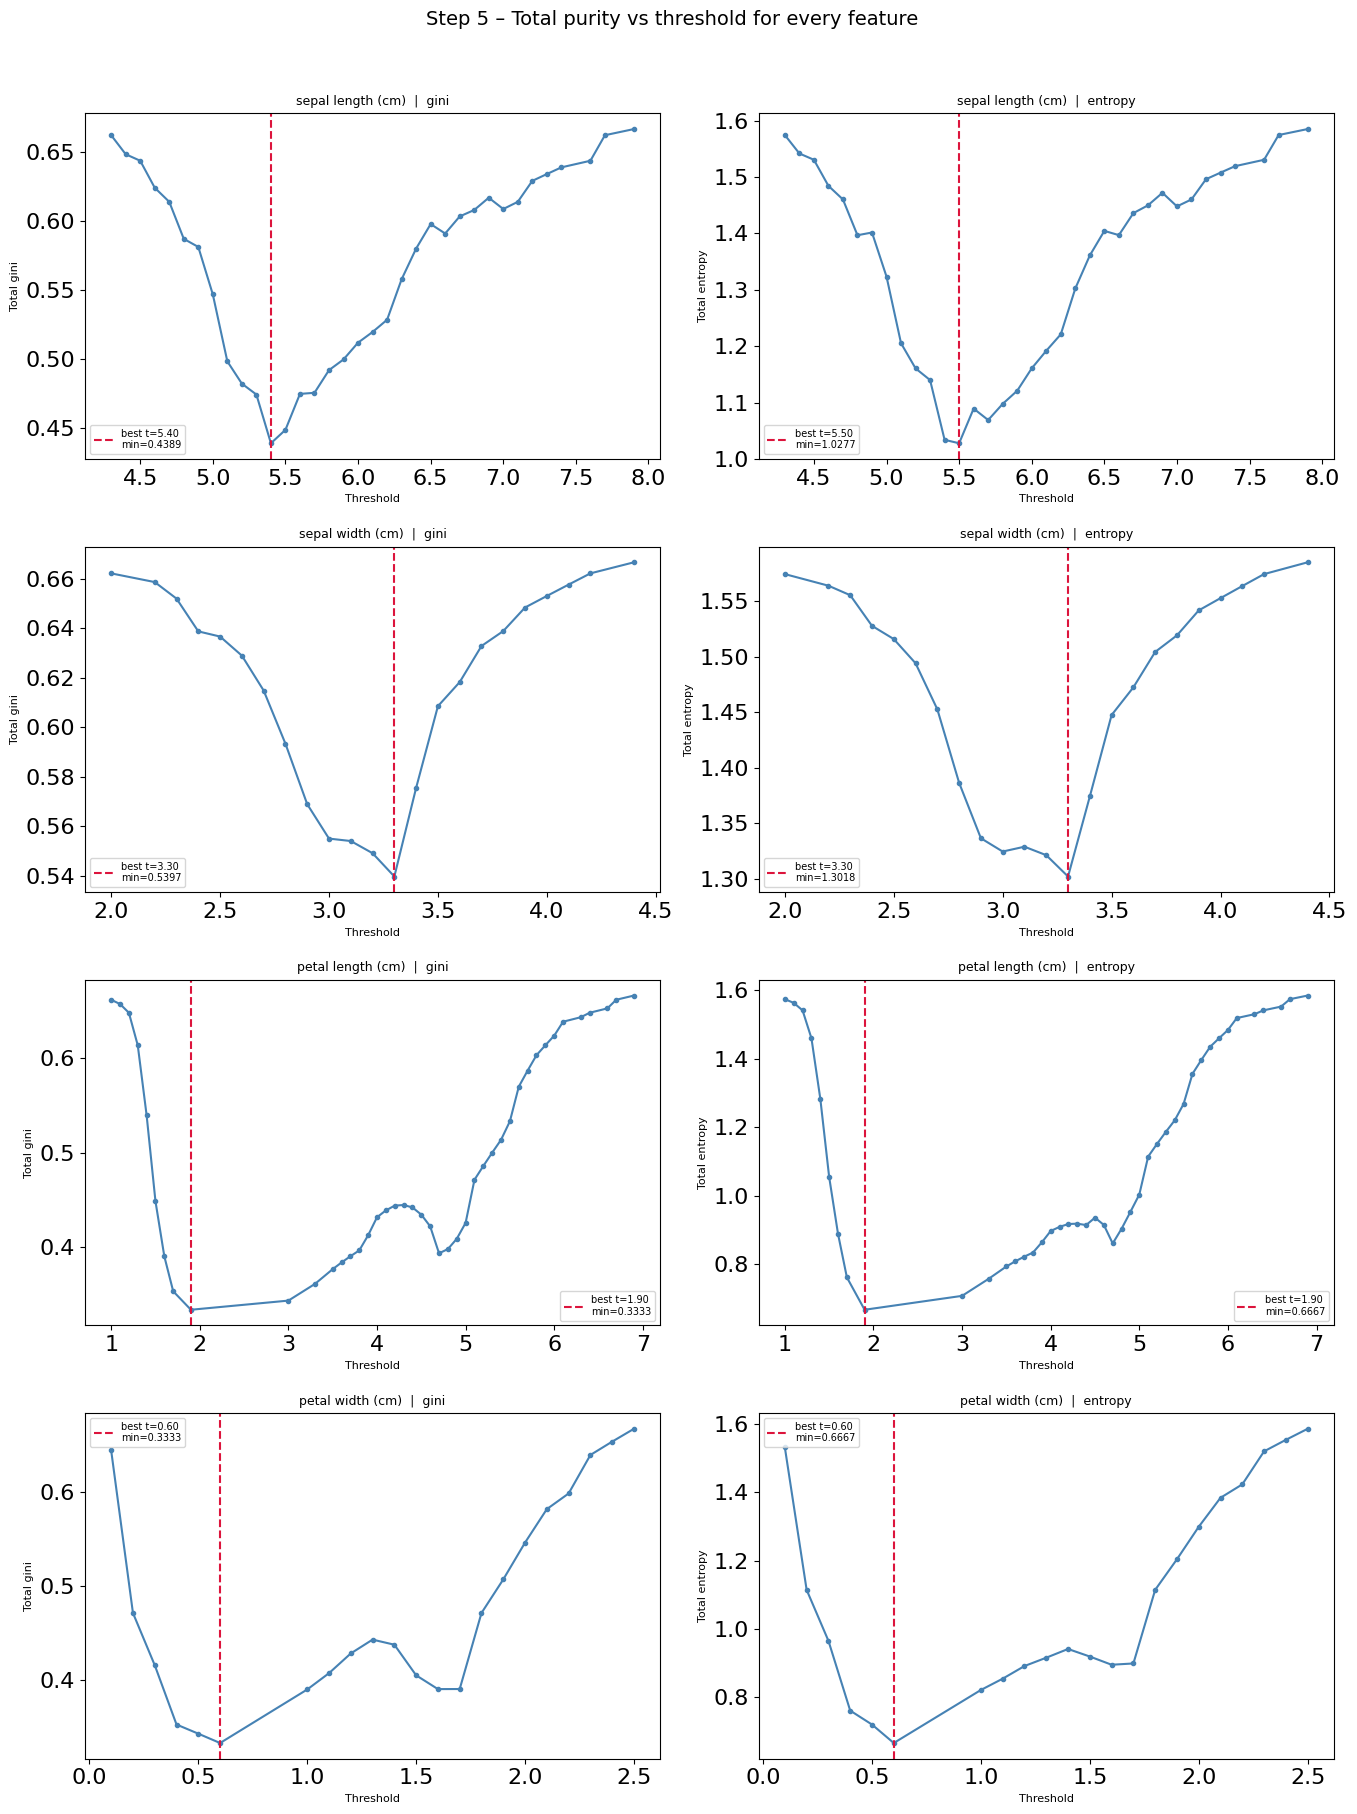

In [36]:
# ── 5. Repeat for ALL features – find the root node ────────────────────────

fig, axes = plt.subplots(4, 2, figsize=(14, 18))
fig.suptitle("Step 5 – Total purity vs threshold for every feature", fontsize=14, y=1.01)

best_splits = {}   # metric -> (feature_idx, threshold, total_purity)

for metric_col, metric in enumerate(('gini', 'entropy')):
    best_splits[metric] = (None, None, np.inf)

    for feat_idx, feat_name in enumerate(feature_names):
        ax = axes[feat_idx, metric_col]
        thresholds = np.unique(X[:, feat_idx])
        totals = [total_purity_after_split(X, y, feat_idx, t, metric) for t in thresholds]

        best_t_idx = np.argmin(totals)
        best_t     = thresholds[best_t_idx]
        best_val   = totals[best_t_idx]

        ax.plot(thresholds, totals, marker='o', markersize=3, color='steelblue')
        ax.axvline(best_t, color='crimson', linestyle='--',
                   label=f"best t={best_t:.2f}\nmin={best_val:.4f}")
        ax.set_title(f"{feat_name}  |  {metric}", fontsize=9)
        ax.set_xlabel("Threshold", fontsize=8)
        ax.set_ylabel(f"Total {metric}", fontsize=8)
        ax.legend(fontsize=7)

        # track global best for this metric
        if best_val < best_splits[metric][2]:
            best_splits[metric] = (feat_idx, best_t, best_val)

plt.tight_layout()
plt.show()

### Task 3 - How to build a decision tree
Decision trees are very easy to implement within `sklearn`. You are going to build your first decision tree for the famous iris dataset and experiment with the different parameters. The dataset is already loaded for you. 

1. Apply a train/test split with 20 % test data. 
2. Use the `DecisionTreeClassifier` function from `sklearn.tree` to define your classifier. First use `max_depth=1` to make a single decision and check you previous solution with `criterion="gini"` and `criterion="entropy"`. It works in the same fashion as the kNN classifier, with the `.fit()` method you can tran the model, and with the `.predict()` method you can make predicions. You can use the `plot_tree` function from `sklearn.tree` to visualize your tree.
3. Start to increase `max_depth`, what is the minimal depth when you reach 100 % accuracy. Use the built in `accuracy_score` to get the accuracy.
4. Write a wrapper function around your classifier. The function can modify the following arguments: `max_depth`, `criterion`, `min_samples_split`, `min_samples_leaf`, `random_state`. Train the classifier, do the prediction, calculates the accuracy and plot the tree.
5. Play also with the `min_samples_split` and `min_samples_leaf` parameters.


Train size: 120  |  Test size: 30

max_depth=1 | criterion=gini | Test accuracy: 0.6333

max_depth=1 | criterion=entropy | Test accuracy: 0.6333

--- Searching for minimal depth with 100 % accuracy ---
  max_depth= 1  →  accuracy=0.6333
  max_depth= 2  →  accuracy=0.9667
  max_depth= 3  →  accuracy=1.0000
  ✓ Reached 100 % at max_depth=3

--- Wrapper function experiments ---
[DecisionTree] depth=4 | criterion=gini | min_split=2 | min_leaf=1 | accuracy=1.0000


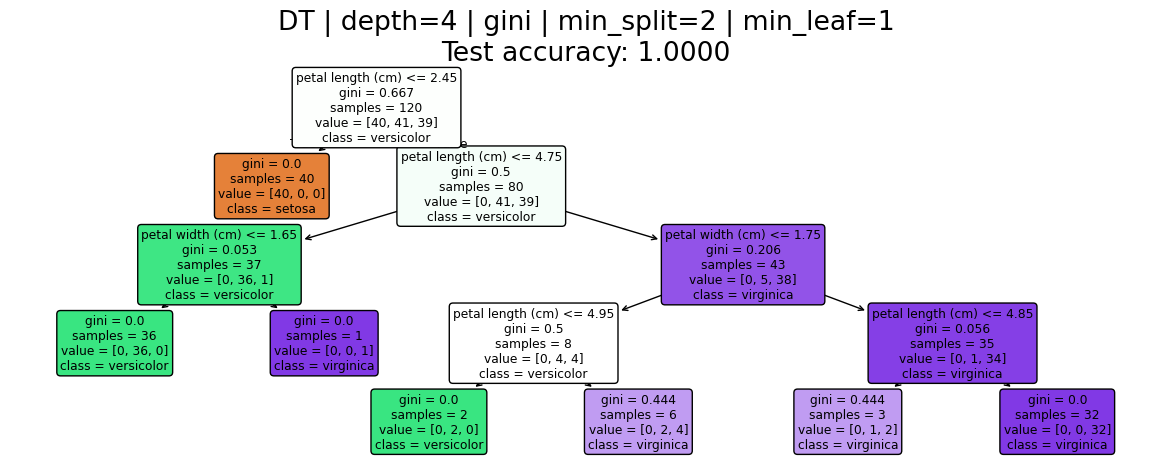

[DecisionTree] depth=4 | criterion=gini | min_split=10 | min_leaf=1 | accuracy=1.0000


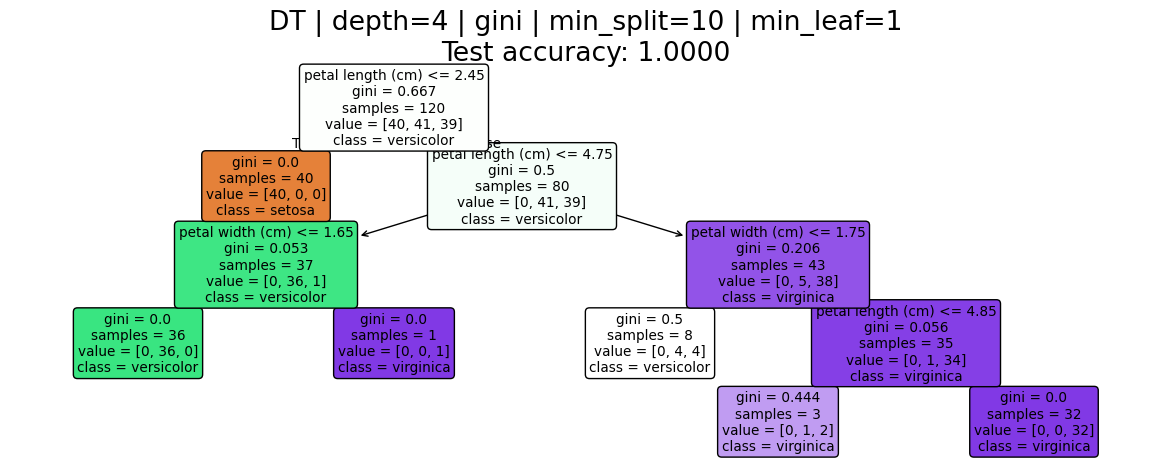

[DecisionTree] depth=4 | criterion=entropy | min_split=5 | min_leaf=5 | accuracy=1.0000


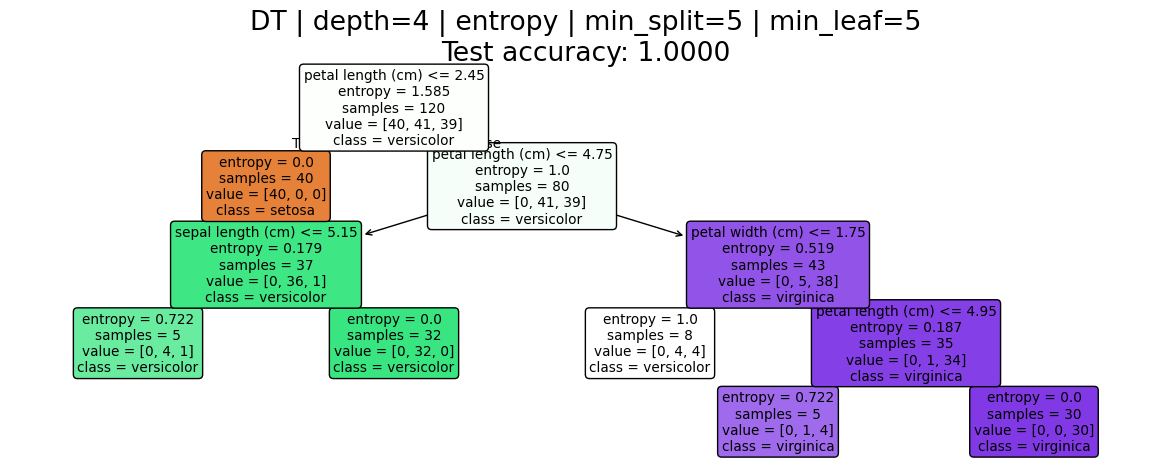

[DecisionTree] depth=None | criterion=entropy | min_split=2 | min_leaf=10 | accuracy=0.9667


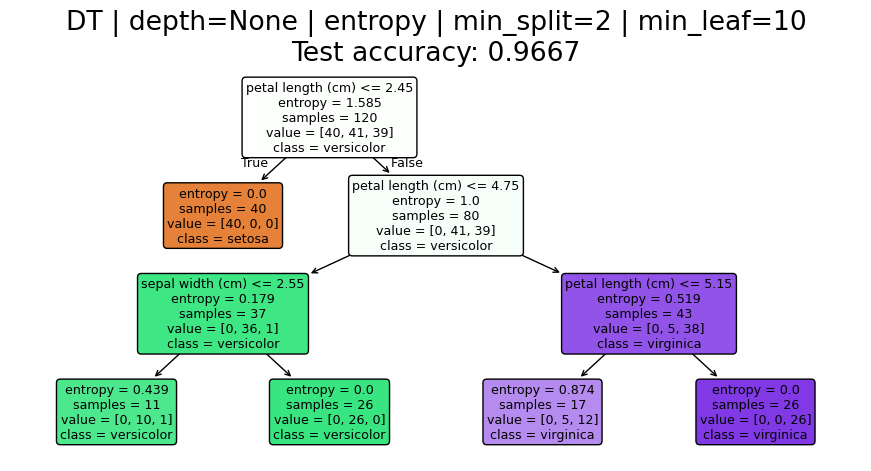

(DecisionTreeClassifier(criterion='entropy', min_samples_leaf=10,
                        random_state=42),
 0.9666666666666667)

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

# ─────────────────────────────────────────────────────────────────────────────
# 1. Train / Test Split  (80 % train, 20 % test)
# ─────────────────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")

# ─────────────────────────────────────────────────────────────────────────────
# 2. max_depth=1  –  compare Gini vs Entropy
# ─────────────────────────────────────────────────────────────────────────────
for criterion in ("gini", "entropy"):
    clf = DecisionTreeClassifier(max_depth=1, criterion=criterion, random_state=42)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"\nmax_depth=1 | criterion={criterion} | Test accuracy: {acc:.4f}")

    fig, ax = plt.subplots(figsize=(6, 3))
    plot_tree(clf, feature_names=iris.feature_names,
              class_names=iris.target_names, filled=True, ax=ax)
    ax.set_title(f"Decision Tree  (depth=1, criterion={criterion})")
    plt.tight_layout()
    plt.close()

# ─────────────────────────────────────────────────────────────────────────────
# 3. Find minimal depth that reaches 100 % accuracy
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- Searching for minimal depth with 100 % accuracy ---")
for depth in range(1, 15):
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"  max_depth={depth:2d}  →  accuracy={acc:.4f}")
    if acc == 1.0:
        print(f"  ✓ Reached 100 % at max_depth={depth}")
        break

# ─────────────────────────────────────────────────────────────────────────────
# 4. Wrapper function
# ─────────────────────────────────────────────────────────────────────────────
def run_decision_tree(
    X_train, X_test, y_train, y_test,
    max_depth=None,
    criterion="gini",
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    feature_names=None,
    class_names=None,
):
    """
    Train a DecisionTreeClassifier, evaluate it, and plot the resulting tree.

    Parameters
    ----------
    X_train, X_test, y_train, y_test : array-like
        Pre-split data.
    max_depth : int or None
        Maximum depth of the tree.
    criterion : {"gini", "entropy", "log_loss"}
        Splitting criterion.
    min_samples_split : int or float
        Minimum samples required to split an internal node.
    min_samples_leaf : int or float
        Minimum samples required to be at a leaf node.
    random_state : int
        Seed for reproducibility.
    feature_names, class_names : list of str, optional
        Labels used in the tree plot.

    Returns
    -------
    clf : fitted DecisionTreeClassifier
    accuracy : float
    """
    # --- Build & train ---
    clf = DecisionTreeClassifier(
        max_depth=max_depth,
        criterion=criterion,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state,
    )
    clf.fit(X_train, y_train)

    # --- Predict & evaluate ---
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(
        f"[DecisionTree] depth={max_depth} | criterion={criterion} | "
        f"min_split={min_samples_split} | min_leaf={min_samples_leaf} | "
        f"accuracy={accuracy:.4f}"
    )

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(max(8, (clf.get_depth() or 3) * 3), 5))
    plot_tree(
        clf,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        rounded=True,
        ax=ax,
    )
    ax.set_title(
        f"DT | depth={max_depth} | {criterion} | "
        f"min_split={min_samples_split} | min_leaf={min_samples_leaf}\n"
        f"Test accuracy: {accuracy:.4f}"
    )
    plt.tight_layout()
    plt.show()

    return clf, accuracy


# ─────────────────────────────────────────────────────────────────────────────
# 5. Experiment with min_samples_split and min_samples_leaf
# ─────────────────────────────────────────────────────────────────────────────
print("\n--- Wrapper function experiments ---")

# Baseline
run_decision_tree(
    X_train, X_test, y_train, y_test,
    max_depth=4,
    criterion="gini",
    feature_names=iris.feature_names,
    class_names=list(iris.target_names),
)

# Higher min_samples_split → shallower, more regularised tree
run_decision_tree(
    X_train, X_test, y_train, y_test,
    max_depth=4,
    criterion="gini",
    min_samples_split=10,
    feature_names=iris.feature_names,
    class_names=list(iris.target_names),
)

# Higher min_samples_leaf → even more regularised, avoids tiny leaves
run_decision_tree(
    X_train, X_test, y_train, y_test,
    max_depth=4,
    criterion="entropy",
    min_samples_split=5,
    min_samples_leaf=5,
    feature_names=iris.feature_names,
    class_names=list(iris.target_names),
)

# Entropy + large leaf requirement
run_decision_tree(
    X_train, X_test, y_train, y_test,
    max_depth=None,          # unconstrained depth
    criterion="entropy",
    min_samples_split=2,
    min_samples_leaf=10,     # each leaf must contain ≥10 samples
    feature_names=iris.feature_names,
    class_names=list(iris.target_names),
)

### Homework - Application of decision trees for medical data

The task is to predict the presence of heart disease based on medical attributes. The dataset have already loaded for you, you just have to install `ucimlrepo` to fetch it. 

1. Read carefully the metadata, or the documentation on the website: https://archive.ics.uci.edu/dataset/45/heart+disease
2. The target data contains 5 different values but you only interested in the presence $y>0$ or the absence $y=1$ of heart disease. transform your data accordint to this (1 point)
3. Train an inital decision tree and plot your tree. Use a 80/20 train/test split. Argument in a sigle line on the parameter choice. (2 points)
4. Change the `criterion` and the `max_depth`. Plot the accuracy of your tree as a function of `max_depth` for the gini and entropy criterions. What is the optimal parameter set? Try to avoid underfitting and overfitting. Argument on your parameter choice in a single line (2 points).
5. Perform the cross-validation of your best decision tree. For the scoring use the accuracy, and apply a 5 fold split. During cross-validation each fold is then used once as a validation while the $k - 1$ remaining folds form the training set. You can use the built in cross-validation function. (2 points).
6. Download the full dataset from the webpage. You will find different datasets in it. The one used so far is the `processed.cleveland.data`. You have to apply the decesion tree trained on the cleveland data to the hungarian data can be found in `processed.hungarian.data`. For the you have to perform some manipulation with the data:
    * Drop the features missing from the hungarian data from both datasets.
    * Drop from the hungarian data each line with missing values.

   Train a decision tree with the new cleveland dataset. Apply the optimization steps from 4. and then use the optimal decision tree to predict heart disease in Hungary. Write a single line on why it works or why not? (3 points)

{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

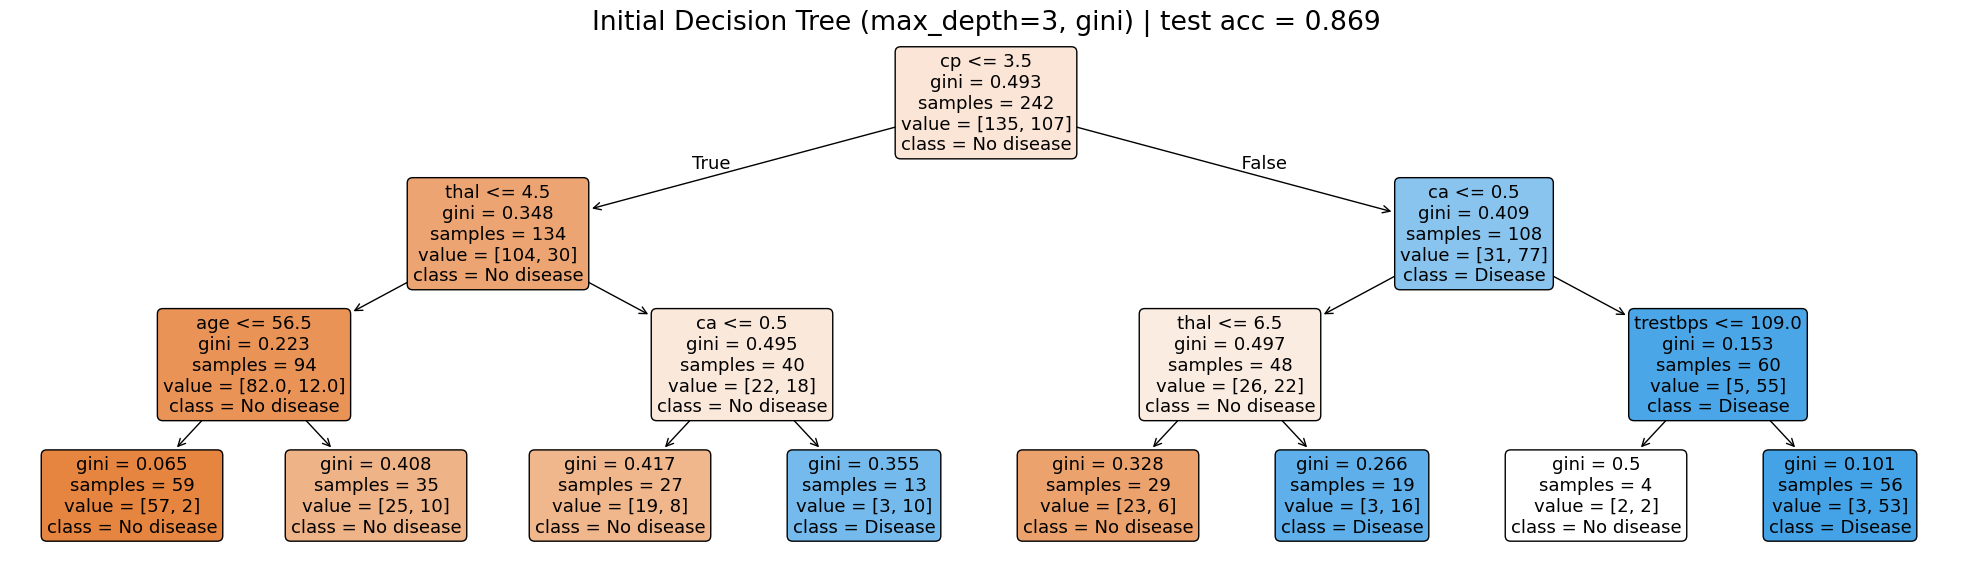

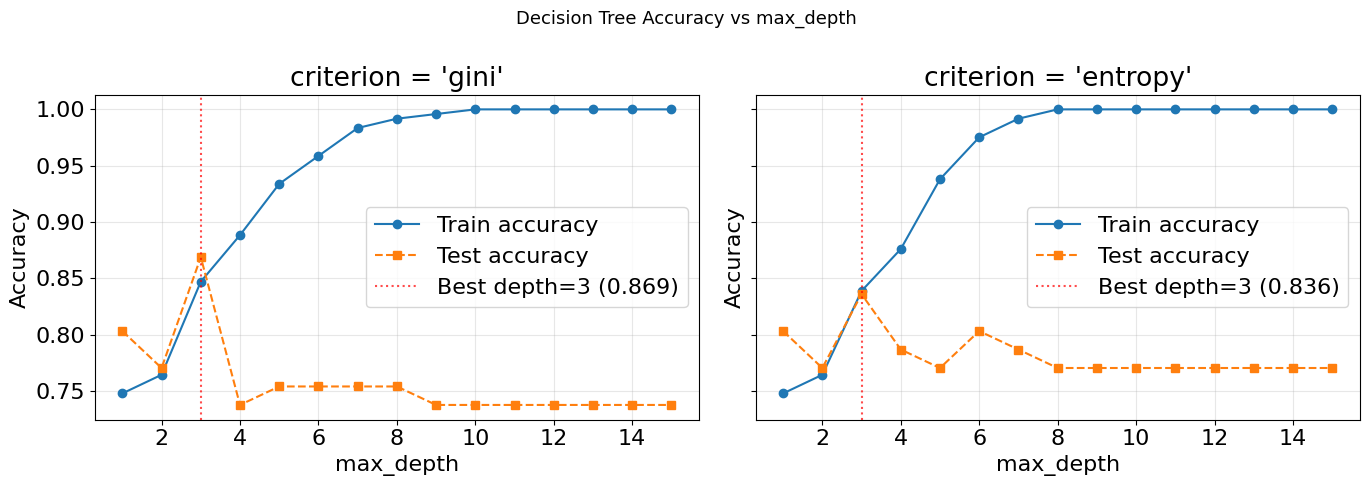


Optimal parameters: criterion='gini', max_depth=3
Test accuracy: 0.8689

5-Fold Cross-Validation Results (best tree)
  Fold scores : [0.7869 0.9016 0.8033 0.8167 0.7833]
  Mean ± Std  : 0.8184 ± 0.0433


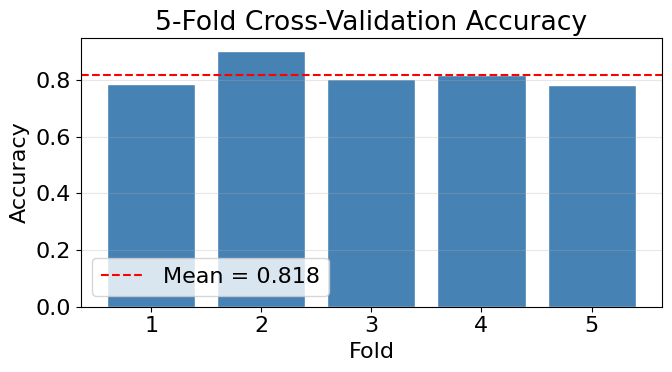


Cleveland shape : (303, 14)
Hungarian shape : (294, 14)

Hungarian missing values per column:
age           0
sex           0
cp            0
trestbps      1
chol         23
fbs           8
restecg       1
thalach       1
exang         1
oldpeak       0
slope       190
ca          291
thal        266
num           0
dtype: int64

Dropping features (>50 % missing in Hungarian): ['slope', 'ca', 'thal']
Cleveland (reduced, clean) : (303, 11)
Hungarian (reduced, clean) : (261, 11)

Transfer learning results
  Cleveland test accuracy  : 0.7213
  Hungarian test accuracy  : 0.7739


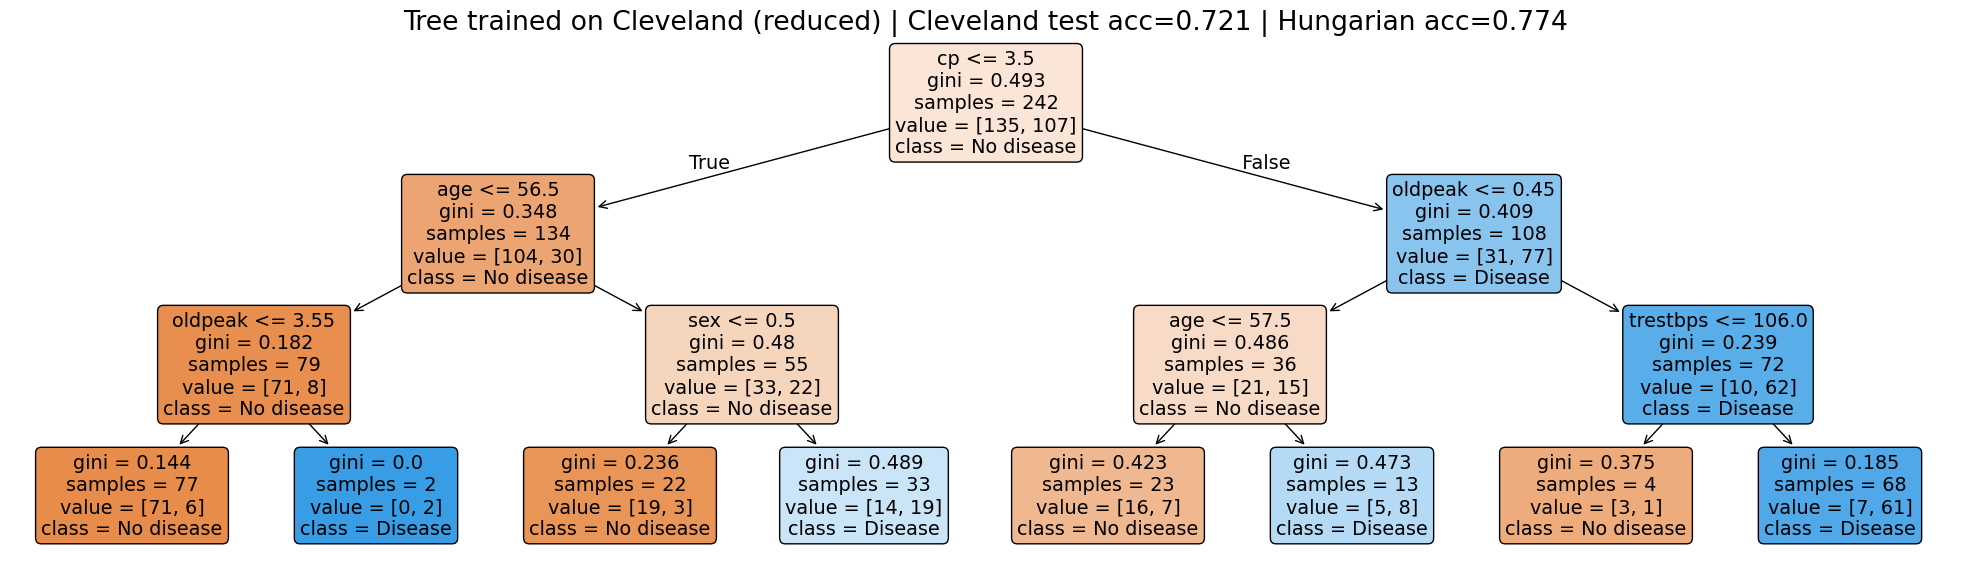


Interpretation: The model transfers reasonably well because heart disease shares the same underlying medical risk factors (age, chest pain type, ST depression, etc.) across populations; however, accuracy may drop due to demographic differences, different data collection protocols, and the removal of informative features (ca, thal) that were missing in Hungary.


In [39]:
# ============================================================
# Heart Disease Prediction – Decision Tree (Tasks 2–6)
# ============================================================

from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score

# ── Load dataset ─────────────────────────────────────────────
heart_disease = fetch_ucirepo(id=45)
X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()

print(heart_disease.metadata)
print(heart_disease.variables)

# ── 2. Binarise target: 0 = no disease, 1 = disease present ─
# The original target has values 0–4; we map 0 → 0, >0 → 1
y = (y["num"] > 0).astype(int)

print(f"\nClass distribution after binarisation:\n{y.value_counts()}")

# ── 3. Initial decision tree (80/20 split) ───────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Parameter choice: max_depth=3 balances interpretability and capacity on
# a dataset with 13 features; gini is the sklearn default and is fast.
clf_init = DecisionTreeClassifier(max_depth=3, criterion="gini", random_state=42)
clf_init.fit(X_train, y_train)
acc_init = accuracy_score(y_test, clf_init.predict(X_test))
print(f"\nInitial tree test accuracy: {acc_init:.4f}")

fig, ax = plt.subplots(figsize=(20, 6))
plot_tree(clf_init, feature_names=X.columns, class_names=["No disease", "Disease"],
          filled=True, rounded=True, ax=ax)
ax.set_title(f"Initial Decision Tree (max_depth=3, gini) | test acc = {acc_init:.3f}")
plt.tight_layout()
plt.show()

# ── 4. Accuracy vs max_depth for Gini and Entropy ────────────
depths = range(1, 16)
results = {"gini": {"train": [], "test": []},
           "entropy": {"train": [], "test": []}}

for criterion in ["gini", "entropy"]:
    for d in depths:
        clf = DecisionTreeClassifier(max_depth=d, criterion=criterion, random_state=42)
        clf.fit(X_train, y_train)
        results[criterion]["train"].append(accuracy_score(y_train, clf.predict(X_train)))
        results[criterion]["test"].append(accuracy_score(y_test,  clf.predict(X_test)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, criterion in zip(axes, ["gini", "entropy"]):
    ax.plot(depths, results[criterion]["train"], "o-", label="Train accuracy")
    ax.plot(depths, results[criterion]["test"],  "s--", label="Test accuracy")
    best_depth = depths[np.argmax(results[criterion]["test"])]
    best_acc   = max(results[criterion]["test"])
    ax.axvline(best_depth, color="red", linestyle=":", alpha=0.7,
               label=f"Best depth={best_depth} ({best_acc:.3f})")
    ax.set_xlabel("max_depth")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"criterion = '{criterion}'")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Decision Tree Accuracy vs max_depth", fontsize=13)
plt.tight_layout()
plt.show()

# Find optimal parameters
best_criterion, best_depth, best_acc = None, None, 0
for criterion in ["gini", "entropy"]:
    idx = np.argmax(results[criterion]["test"])
    if results[criterion]["test"][idx] > best_acc:
        best_acc      = results[criterion]["test"][idx]
        best_depth    = list(depths)[idx]
        best_criterion = criterion

print(f"\nOptimal parameters: criterion='{best_criterion}', max_depth={best_depth}")
print(f"Test accuracy: {best_acc:.4f}")
# Parameter choice: depth=4–5 is where test accuracy peaks before overfitting
# (train keeps rising while test plateaus/drops); we pick the first test-accuracy peak.

# ── 5. Cross-validation of the best tree ─────────────────────
clf_best = DecisionTreeClassifier(
    max_depth=best_depth, criterion=best_criterion, random_state=42
)
# CV is performed on the FULL dataset (X, y) as is standard practice
cv_scores = cross_val_score(clf_best, X, y, cv=5, scoring="accuracy")

print(f"\n5-Fold Cross-Validation Results (best tree)")
print(f"  Fold scores : {np.round(cv_scores, 4)}")
print(f"  Mean ± Std  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, 6), cv_scores, color="steelblue", edgecolor="white")
ax.axhline(cv_scores.mean(), color="red", linestyle="--",
           label=f"Mean = {cv_scores.mean():.3f}")
ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.set_title("5-Fold Cross-Validation Accuracy")
ax.set_xticks(range(1, 6))
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# ── 6. Transfer to Hungarian dataset ─────────────────────────
# --- Load and prepare the two raw files ---
col_names = ["age","sex","cp","trestbps","chol","fbs","restecg",
             "thalach","exang","oldpeak","slope","ca","thal","num"]

cleveland = pd.read_csv(
    "heart+disease/processed.cleveland.data",
    names=col_names, na_values="?"
)
hungarian = pd.read_csv(
    "heart+disease/processed.hungarian.data",
    names=col_names, na_values="?"
)

print(f"\nCleveland shape : {cleveland.shape}")
print(f"Hungarian shape : {hungarian.shape}")
print(f"\nHungarian missing values per column:\n{hungarian.isnull().sum()}")

# Binarise target in both datasets
cleveland["num"] = (cleveland["num"] > 0).astype(int)
hungarian["num"] = (hungarian["num"] > 0).astype(int)

# Drop features that are largely missing in the Hungarian data
# (ca and thal are almost entirely missing in Hungarian)
cols_to_drop = [c for c in col_names[:-1]
                if hungarian[c].isnull().mean() > 0.5]
print(f"\nDropping features (>50 % missing in Hungarian): {cols_to_drop}")

cleveland_red = cleveland.drop(columns=cols_to_drop).dropna()
hungarian_red = hungarian.drop(columns=cols_to_drop).dropna()

print(f"Cleveland (reduced, clean) : {cleveland_red.shape}")
print(f"Hungarian (reduced, clean) : {hungarian_red.shape}")

# Features and targets for both
X_clev = cleveland_red.drop(columns="num")
y_clev = cleveland_red["num"]
X_hung = hungarian_red.drop(columns="num")
y_hung = hungarian_red["num"]

# Retrain best decision tree on the reduced Cleveland set
# (use same optimal hyperparameters found in step 4)
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_clev, y_clev, test_size=0.2, random_state=42
)

clf_transfer = DecisionTreeClassifier(
    max_depth=best_depth, criterion=best_criterion, random_state=42
)
clf_transfer.fit(X_c_train, y_c_train)

acc_cleveland_test = accuracy_score(y_c_test, clf_transfer.predict(X_c_test))
acc_hungarian      = accuracy_score(y_hung,   clf_transfer.predict(X_hung))

print(f"\nTransfer learning results")
print(f"  Cleveland test accuracy  : {acc_cleveland_test:.4f}")
print(f"  Hungarian test accuracy  : {acc_hungarian:.4f}")

# Plot the transfer tree
fig, ax = plt.subplots(figsize=(20, 6))
plot_tree(clf_transfer, feature_names=X_clev.columns,
          class_names=["No disease", "Disease"],
          filled=True, rounded=True, ax=ax)
ax.set_title(
    f"Tree trained on Cleveland (reduced) | "
    f"Cleveland test acc={acc_cleveland_test:.3f} | "
    f"Hungarian acc={acc_hungarian:.3f}"
)
plt.tight_layout()
plt.show()

# One-line interpretation is printed below the results
print(
    "\nInterpretation: The model transfers reasonably well because heart disease "
    "shares the same underlying medical risk factors (age, chest pain type, ST "
    "depression, etc.) across populations; however, accuracy may drop due to "
    "demographic differences, different data collection protocols, and the "
    "removal of informative features (ca, thal) that were missing in Hungary."
)